### Optimal control of noisy aLN model: State transitions in single-node

This notebook demonstrates how to compute the optimal control (OC) signal in a noisy system.

We consider the control task to transition in a bistable state of coesxisitng up state and oscillations in the aLN (mean-field EIF) model. This task is studied in detail in Reference [1]. Here, we compute the OC for a noisy setup for three different noise strength.


In [1]:
# load modules and set up the environment
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

while os.getcwd().split(os.sep)[-1] != "neurolib":
    os.chdir('..')

# We import the model, stimuli, and the optimal control package
from neurolib.models.wc import WCModel
from neurolib.models.aln import ALNModel

from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, oc_aln, cost_functions

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

datadir = os.path.join("examples", "data")

In [2]:
# This function reads out the final state of a simulation
def getfinalstate(model):
    N = model.params.Cmat.shape[0]
    V = len(model.state_vars)
    T = model.getMaxDelay() + 1
    state = np.zeros((N, V, T))
    for v in range(V):
        if "rates" in model.state_vars[v] or "IA" in model.state_vars[v]:
            for n in range(N):
                state[n, v, :] = model.state[model.state_vars[v]][n, -T:]
        else:
            for n in range(N):
                state[n, v, :] = model.state[model.state_vars[v]][n]
    return state

# This function sets the initial state of a model to specific values
def setinitstate(model, state):
    N = model.params.Cmat.shape[0]
    V = len(model.init_vars)
    T = model.getMaxDelay() + 1

    for n in range(N):
        for v in range(V):
            if "rates" in model.init_vars[v] or "IA" in model.init_vars[v]:
                model.params[model.init_vars[v]] = state[:, v, -T:]
            else:
                model.params[model.init_vars[v]] = state[:, v, -1]

    return


# compute the oscillation period of a state trajectory
def getperiod(data, dt):
    maxfreq = []
    for i_d,d in enumerate(data):
        ps = np.abs(np.fft.fft(d))
        ps_ = ps[:int(len(ps)/2)] / (len(ps)/2)
        ps_[0] = 0.
        fr = np.linspace(0,1./(2.*dt),len(ps_))
        maxfreqind = np.where(ps_ == max(ps_[1:]))
        maxfreq.append((1./fr[maxfreqind])[0])

    return np.mean(maxfreq)

First, we consider the noise-free system. We use the same state-space location as in Reference [1]. We loas the previously computed data and read the parameters the define the control task. We simulate the system to arrive at the initial state.

The following notebook may have to be run several times, until one finds an oscillatory state in the final plot.

[1]: L. Salfenmoser and K. Obermayer. A framework for optimal control of oscillations and synchrony applied to nonlinear models of neural population dynamics. Frontiers in Computational Neuroscience 18 (2024). Available at https://doi.org/10.3389/fncom.2024.1483100.

[1.9, 1.5]


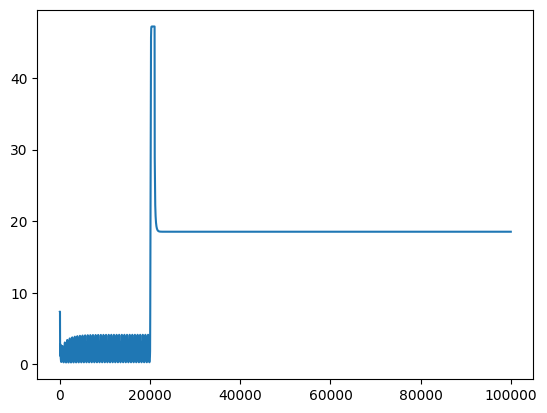

natural period =  58.06322580645162
[1.65627065 1.67784713 1.70058303 1.72331479 1.74603811 1.76874435
 1.79141387 1.81402681 1.83660857 1.85915292]
natural period =  58.06322580645162


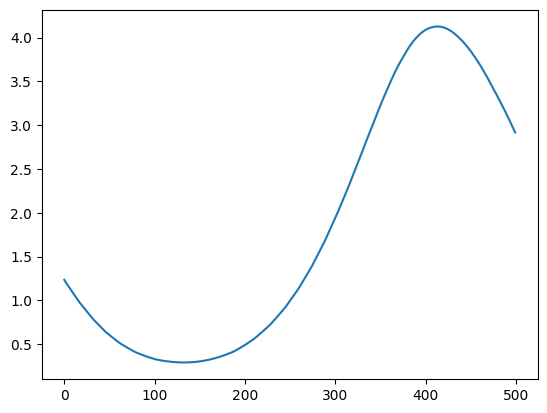

In [7]:
# we set parameters as in the control task discussed in Reference [1] and load the OC computed for the noise-free system
# this cell should be run until the system ends up in an oscillatory state; otherwise we cannot measure the oscillation period
with open(os.path.join(datadir, 'ss_aln.pickle'), 'rb') as f:
    res_read = pickle.load(f)

data = res_read.copy()

N = 1
aln = ALNModel()
dt = aln.params.dt
testd = 1.*1e4
aln.params.duration = testd
aln.params.mue_ext_mean = data["coordinates"][0]
aln.params.mui_ext_mean = data["coordinates"][1]

print(data["coordinates"])

test_input = ZeroInput().generate_input(duration=testd+aln.params.dt, dt=aln.params.dt)
test_input[0,int(2000/dt):int(2100/dt)] = .6
aln.params["ext_exc_current"] = test_input
aln.params["ext_inh_current"] = test_input

aln.run()
plt.plot(aln.rates_exc[0,:])
plt.show()

test_input[0,int(2000/dt):int(2100/dt)] = -0.3

aln.params["ext_exc_current"] = test_input
aln.params["ext_inh_current"] = test_input

aln.run()
plt.plot(aln.rates_exc[0,-500:])

natural_period = getperiod([aln.rates_exc[0,int(1000/dt):]], dt)
print("natural period = ", natural_period)

print(data["init_state"][1][0,0,-10:])

natural_period = getperiod([aln.rates_exc[0,int(1000/dt):]], dt)
print("natural period = ", natural_period)

We set the hyperparamters of the optimal control computation.

In [8]:
# hyperparamters of the OC computation
controlmat = np.zeros((1,4))
controlmat[0,0] = 1

costmat = np.zeros((1, 3))
costmat[:,0] = 1.

duration = 1000.
int0 = 1000
int1 = 5000
int2 = 6000

max_cntrl = 5
pr = np.arange(0,101,10)

We initialize the OC model and set further hyperparameters.

In [9]:
ci = 0 # up to osc task

aln = ALNModel()
setinitstate(aln, data["init_state"][ci])
aln.params["mue_ext_mean"] =  data["coordinates"][0]
aln.params["mui_ext_mean"] =  data["coordinates"][1]
aln.params.duration = duration

aln.run()

aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
aln_controlled.weights["w_p"] = 0.
aln_controlled.weights["w_2"] = 1.
aln_controlled.weights["w_f_osc"] = data["weights"][ci]

aln_controlled.control = data["control_unshifted"][ci].copy()
aln_controlled.update_input()
aln_controlled.optimize(0)

Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.0002493056410964173
Final cost : -0.0002493056410964173


The control algorithm averages over a specified number M of realizations to find a robust control in a noisy environment. The OC module contains a function find_M that helps to decide for a reasonable number M. For reproducibility, we chose numbers that are close to, but may not agree with the result of this function.

In [ ]:
sigma_array = [3 * 1e-3, 12. * 1e-3, 48. * 1e-3] # array of noise strength
M_array = [1, 1, 1] #  initial values for M

ci = 0

for si, sigma in enumerate(sigma_array):
    aln = ALNModel()
    setinitstate(aln, data["init_state"][ci])
    aln.params["mue_ext_mean"] =  data["coordinates"][0]
    aln.params["mui_ext_mean"] =  data["coordinates"][1]
    aln.params.duration = duration
    aln.params["sigma_ou"] =  sigma

    aln.params["ext_exc_current"] = np.zeros_like(data["control"][ci].copy()[:,0,:])
    aln.run()

    aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat, 
                                  M=2, M_validation=400, validate_per_step=True)


    M_array[si] = aln_controlled.find_M(sigma)
    print("M = ", M_array[si])

M_array = [5, 12, 30] #  final values for M, in approximate agreement with the result of the function find_M

Optimal control with target oscillation period
M =  5
Optimal control with target oscillation period
M =  14
Optimal control with target oscillation period
M =  30


In [14]:
# define the data to be overwritten with the results and stored
counter_doc = np.zeros((2, 3))
counter_noinput = np.zeros((2, 3))
counter_noc = np.zeros((2, 3, 3))

control_array = [ [[None, None, None], [None, None, None], [None, None, None]],
                  [[None, None, None], [None, None, None], [None, None, None]] ]

Finally, we compute the optimal control in the noisy system. This may take several hours. 

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -1.2883786089000202
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -1.1840507973590875
Compute control for a noisy system
Mean cost in iteration 0: -1.3695827250821362
Minimal cost found at iteration 1
Final cost validated with 400 noise realizations : -820.0589890309736
Compute control for a noisy system
Mean cost in iteration 0: -821.6653037579679
Minimal cost found at iteration 1
Final cost validated with 400 noise realizations : -819.0068523675731
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -81.78316507147682
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -82.05777765056695
Compute control for a noisy system
Mean cost in iteration 0: -82.09071746150994
Mean cost in iteration 10: -80.352198506828
Mean cost in iteration 20: -80.159034017340

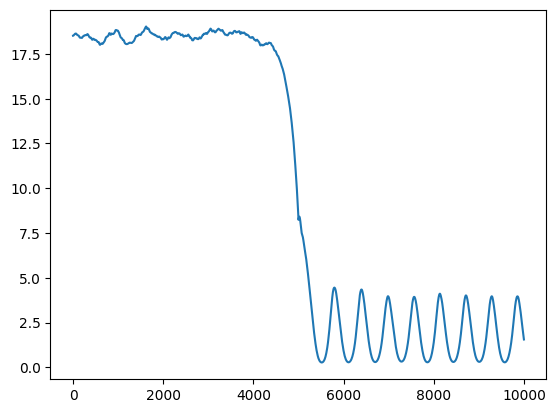

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -821.687117636777
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -819.0929960409553
Compute control for a noisy system
Mean cost in iteration 0: -818.398872920644
Minimal cost found at iteration 3
Final cost validated with 400 noise realizations : -821.9814145015172
Compute control for a noisy system
Mean cost in iteration 0: -816.8364220438461
Minimal cost found at iteration 8
Final cost validated with 400 noise realizations : -819.6476643014088
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -81.91908267629447
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -81.96670811861571
Compute control for a noisy system
Mean cost in iteration 0: -82.39460026014761
Mean cost in iteration 10: -81.27895671434278
Mean cost in iteration 20: -80.89891850757151


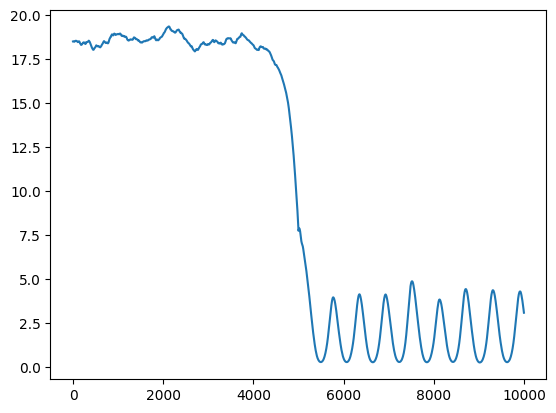

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -820.1557745372348
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -823.2256591800631
Compute control for a noisy system
Mean cost in iteration 0: -821.877133984704
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -820.6418071971583
Compute control for a noisy system
Mean cost in iteration 0: -821.026226606025
Minimal cost found at iteration 8
Final cost validated with 400 noise realizations : -820.6790895692254
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -82.0397203115415
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -81.91695315296779
Compute control for a noisy system
Mean cost in iteration 0: -81.7189916113892
Mean cost in iteration 10: -81.83089753250732
Mean cost in iteration 20: -81.8548277175753
Mea

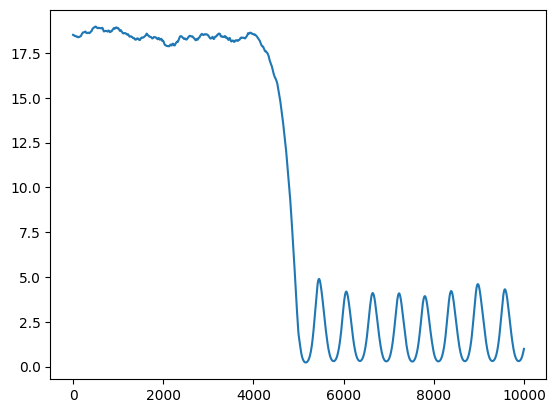

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -19.361241294589266
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -20.637327409882186
Compute control for a noisy system
Mean cost in iteration 0: -22.392117707315883
Minimal cost found at iteration 4
Final cost validated with 400 noise realizations : -526.5734074854171
Compute control for a noisy system
Mean cost in iteration 0: -538.4837316923517
Minimal cost found at iteration 5
Final cost validated with 400 noise realizations : -529.0916374839035
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -52.61920596701204
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -53.33284206552548
Compute control for a noisy system
Mean cost in iteration 0: -53.38536796426476
Mean cost in iteration 10: -52.96114965185224
Mean cost in iteration 20: -52.4395601714

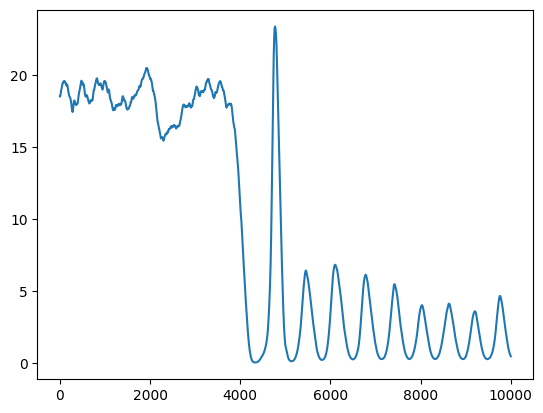

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -538.2140296706643
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -530.6895324351419
Compute control for a noisy system
Mean cost in iteration 0: -538.6953092277504
Minimal cost found at iteration 4
Final cost validated with 400 noise realizations : -525.0943452246598
Compute control for a noisy system
Mean cost in iteration 0: -511.0738040801864
Minimal cost found at iteration 4
Final cost validated with 400 noise realizations : -530.0169817300067
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -53.55879388495097
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -48.93177632814532
Compute control for a noisy system
Mean cost in iteration 0: -54.19096030926832
Mean cost in iteration 10: -52.45148628587508
Mean cost in iteration 20: -52.8416229140691

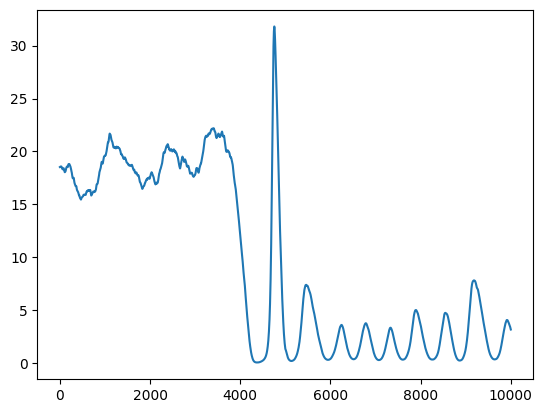

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -555.3192723313342
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -554.5975132920559
Compute control for a noisy system
Mean cost in iteration 0: -555.6490928004768
Minimal cost found at iteration 3
Final cost validated with 400 noise realizations : -544.9075356649738
Compute control for a noisy system
Mean cost in iteration 0: -553.8446478974988
Minimal cost found at iteration 3
Final cost validated with 400 noise realizations : -545.7184117846994
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -52.00261900951361
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -51.381201055190665
Compute control for a noisy system
Mean cost in iteration 0: -52.27695173445968
Mean cost in iteration 10: -50.89906490320225
Mean cost in iteration 20: -53.513703662242

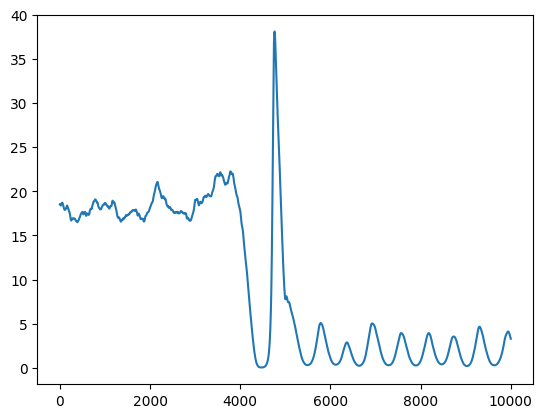

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -329.2644052885126
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -364.01906168166164
Compute control for a noisy system
Mean cost in iteration 0: -361.7366604274679
Minimal cost found at iteration 1
Final cost validated with 400 noise realizations : -356.9669900994299
Compute control for a noisy system
Mean cost in iteration 0: -401.70700287584236
Minimal cost found at iteration 8
Final cost validated with 400 noise realizations : -366.6644172008488
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -36.95760572668133
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -36.56753143307683
Compute control for a noisy system
Mean cost in iteration 0: -34.91798789981003
Mean cost in iteration 10: -34.679192627008426
Mean cost in iteration 20: -32.1059004386

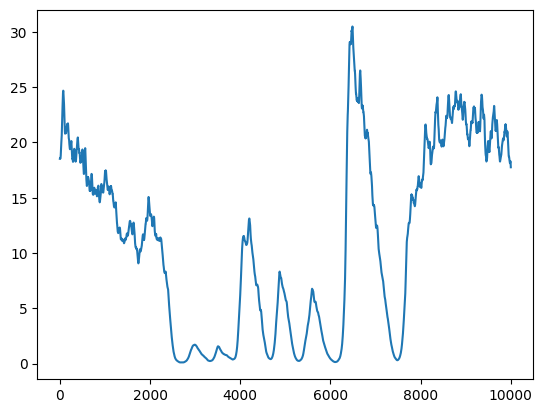

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -359.8805574659242
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -356.22224482040156
Compute control for a noisy system
Mean cost in iteration 0: -306.77684785641566
Minimal cost found at iteration 2
Final cost validated with 400 noise realizations : -369.36903311326074
Compute control for a noisy system
Mean cost in iteration 0: -344.25381098278706
Minimal cost found at iteration 2
Final cost validated with 400 noise realizations : -326.93740810388306
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -30.32040189206436
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -27.930917552006125
Compute control for a noisy system
Mean cost in iteration 0: -28.298519459695623
Mean cost in iteration 10: -27.295972851721878
Mean cost in iteration 20: -33.26756

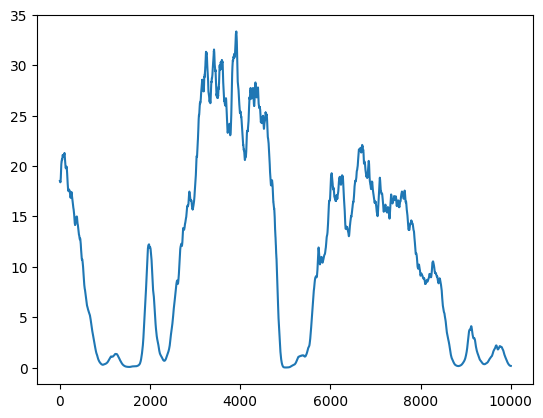

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -361.79250187696846
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -352.6795610572161
Compute control for a noisy system
Mean cost in iteration 0: -360.8771361725591
Minimal cost found at iteration 3
Final cost validated with 400 noise realizations : -384.2032040538576
Compute control for a noisy system
Mean cost in iteration 0: -342.16001927027935
Minimal cost found at iteration 3
Final cost validated with 400 noise realizations : -363.0689747009382
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -29.224656884997003
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : -32.54103099610799
Compute control for a noisy system
Mean cost in iteration 0: -29.40332674577614
Mean cost in iteration 10: -33.185986363290866
Mean cost in iteration 20: -30.547583038

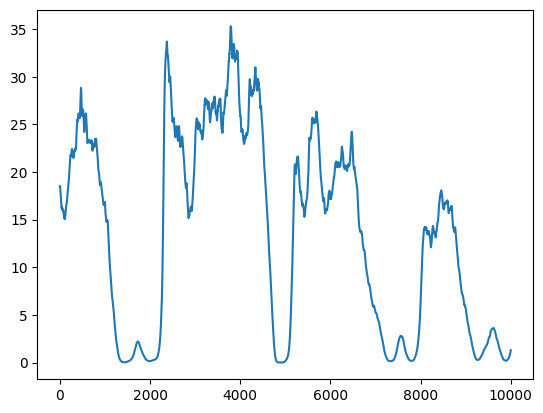

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: 0.7922925818209179
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.794858045470528
Compute control for a noisy system
Mean cost in iteration 0: 0.7943772282100522
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.793433190982452
Compute control for a noisy system
Mean cost in iteration 0: 0.7934538529031749
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.7925792529856142
Compute control for a noisy system
Mean cost in iteration 0: 0.7922734177669812
Mean cost in iteration 10: 0.2297396449313981
Mean cost in iteration 20: 0.23042113566601752
Mean cost in iteration 30: 0.2224541569375175
Mean cost in iteration 40: 0.2281863068145626
Mean cost in iteration 50: 0.22647652295665793
Mean cost in iteration 60: 0.2239622109891136
Mean cost in iteration 70: 0.2491771278548479

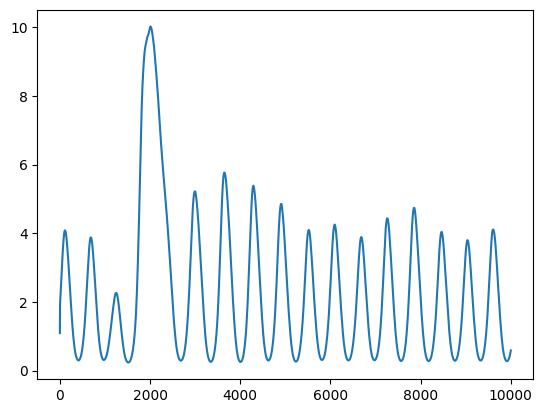

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: 0.2289187626064236
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.22638651033174034
Compute control for a noisy system
Mean cost in iteration 0: 0.23679989240888305
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.21996630807404116
Compute control for a noisy system
Mean cost in iteration 0: 0.21826362899040944
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.23829473993994302
Compute control for a noisy system
Mean cost in iteration 0: 0.2201175744204584
Mean cost in iteration 10: 0.2514943095414645
Mean cost in iteration 20: 0.25132301976396365
Mean cost in iteration 30: 0.25154044762137034
Mean cost in iteration 40: 0.25133970814524637
Mean cost in iteration 50: 0.2514903633306999
Mean cost in iteration 60: 0.25145372476887734
Mean cost in iteration 70: 0.2514081

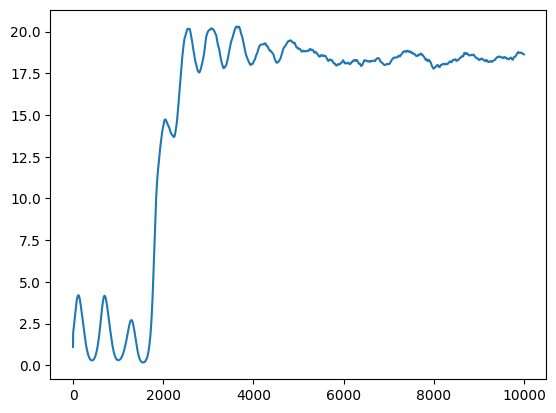

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: 0.2283218888029609
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.2242316889168994
Compute control for a noisy system
Mean cost in iteration 0: 0.22603185341674467
Minimal cost found at iteration 2
Final cost validated with 400 noise realizations : 0.24030184326123183
Compute control for a noisy system
Mean cost in iteration 0: 0.2393656277614382
Minimal cost found at iteration 8
Final cost validated with 400 noise realizations : 0.12799949745061381
Compute control for a noisy system
Mean cost in iteration 0: 0.13195172769678318
Mean cost in iteration 10: 0.13672543280834107
Mean cost in iteration 20: 0.13467198909412456
Mean cost in iteration 30: 0.134757488575653
Mean cost in iteration 40: 0.13460812167175715
Mean cost in iteration 50: 0.13467849786666247
Mean cost in iteration 60: 0.1346573399131846
Mean cost in iteration 70: 0.134621835

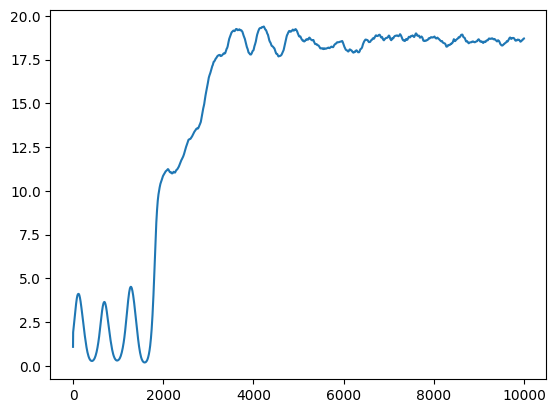

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: 0.5526841444100349
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.5599756656817736
Compute control for a noisy system
Mean cost in iteration 0: 0.5376667283341061
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.5415718794966906
Compute control for a noisy system
Mean cost in iteration 0: 0.567934166581332
Minimal cost found at iteration 6
Final cost validated with 400 noise realizations : 0.4511243481323415
Compute control for a noisy system
Mean cost in iteration 0: 0.4492798698834531
Mean cost in iteration 10: 0.43818343182278147
Mean cost in iteration 20: 0.4408250635666495
Mean cost in iteration 30: 0.4347817155052865
Mean cost in iteration 40: 0.4386689536897093
Mean cost in iteration 50: 0.4416090542126935
Mean cost in iteration 60: 0.43754179446679736
Mean cost in iteration 70: 0.437255070347159

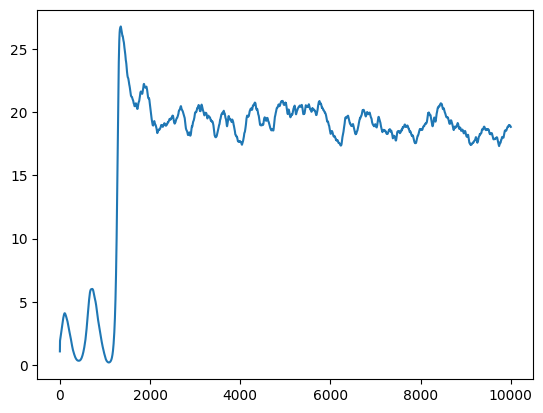

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: 0.4412750798458236
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.4426746041317356
Compute control for a noisy system
Mean cost in iteration 0: 0.44141416232806874
Minimal cost found at iteration 1
Final cost validated with 400 noise realizations : 0.2360469926523396
Compute control for a noisy system
Mean cost in iteration 0: 0.21483378852497526
Minimal cost found at iteration 6
Final cost validated with 400 noise realizations : 0.22680519683912465
Compute control for a noisy system
Mean cost in iteration 0: 0.22193839710800012
Mean cost in iteration 10: 0.21584292971327323
Mean cost in iteration 20: 0.20736520728432392
Mean cost in iteration 30: 0.21429112019527585
Mean cost in iteration 40: 0.20399518316516438
Mean cost in iteration 50: 0.22299032570870672
Mean cost in iteration 60: 0.221782406307632
Mean cost in iteration 70: 0.21722392

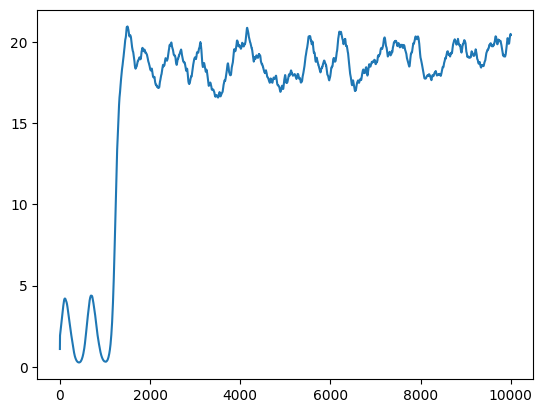

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: 0.22040820969379996
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.22116190204516617
Compute control for a noisy system
Mean cost in iteration 0: 0.2184540985667622
Minimal cost found at iteration 1
Final cost validated with 400 noise realizations : 0.2063882477452117
Compute control for a noisy system
Mean cost in iteration 0: 0.21853160506774547
Minimal cost found at iteration 1
Final cost validated with 400 noise realizations : 0.22990050639833048
Compute control for a noisy system
Mean cost in iteration 0: 0.21367958583942076
Mean cost in iteration 10: 0.23545315069386785
Mean cost in iteration 20: 0.20698313639363877
Mean cost in iteration 30: 0.2569655740393897
Mean cost in iteration 40: 0.23058129655692544
Mean cost in iteration 50: 0.23907096948036494
Mean cost in iteration 60: 0.23938357856337095
Mean cost in iteration 70: 0.234811

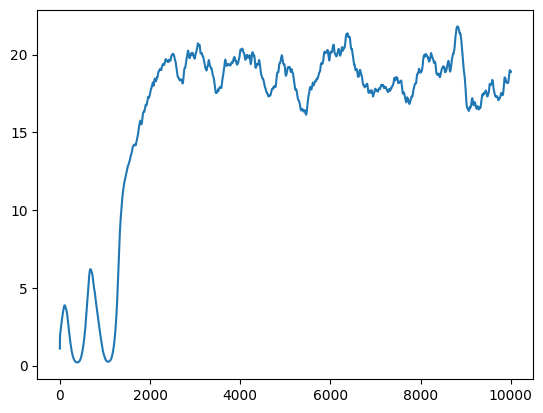

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: 0.3914209786205706
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.3851330316734941
Compute control for a noisy system
Mean cost in iteration 0: 0.34680057079600923
Minimal cost found at iteration 2
Final cost validated with 400 noise realizations : 0.37653825499377225
Compute control for a noisy system
Mean cost in iteration 0: 0.3679496869751865
Minimal cost found at iteration 2
Final cost validated with 400 noise realizations : 0.35837111405162425
Compute control for a noisy system
Mean cost in iteration 0: 0.361829150214396
Mean cost in iteration 10: 0.4389922745330918
Mean cost in iteration 20: 0.38124658321257593
Mean cost in iteration 30: 0.39152603312991857
Mean cost in iteration 40: 0.37155593703228973
Mean cost in iteration 50: 0.4053076064664286
Mean cost in iteration 60: 0.40111629849394725
Mean cost in iteration 70: 0.4114677416

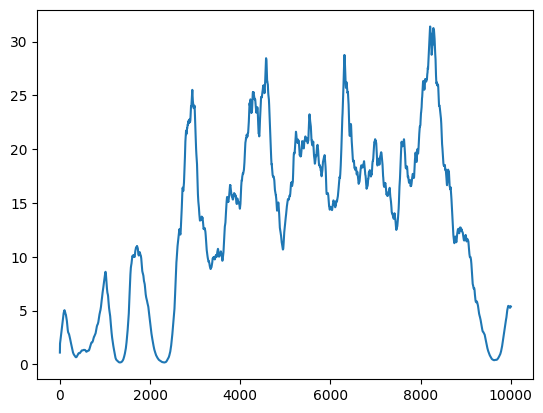

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: 0.3662504578029505
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.3753132929921541
Compute control for a noisy system
Mean cost in iteration 0: 0.35682745561983464
Minimal cost found at iteration 1
Final cost validated with 400 noise realizations : 0.38429147096776156
Compute control for a noisy system
Mean cost in iteration 0: 0.41319282960534925
Minimal cost found at iteration 1
Final cost validated with 400 noise realizations : 0.3868929391760033
Compute control for a noisy system
Mean cost in iteration 0: 0.41391780985161025
Mean cost in iteration 10: 0.36529647245050895
Mean cost in iteration 20: 0.36824538014353814
Mean cost in iteration 30: 0.38175447915193805
Mean cost in iteration 40: 0.3869426638996968
Mean cost in iteration 50: 0.3998265101509826
Mean cost in iteration 60: 0.38307379949638937
Mean cost in iteration 70: 0.37030908

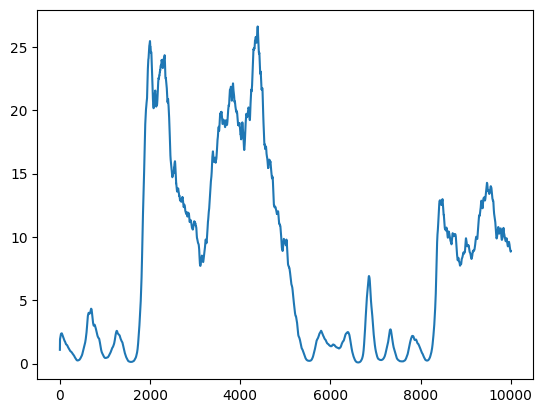

Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: 0.3985046060004405
Minimal cost found at iteration 0
Final cost validated with 400 noise realizations : 0.3667684189534432
Compute control for a noisy system
Mean cost in iteration 0: 0.4188400768312311
Minimal cost found at iteration 4
Final cost validated with 400 noise realizations : 0.3671234765072483
Compute control for a noisy system
Mean cost in iteration 0: 0.36323394492138994
Minimal cost found at iteration 4
Final cost validated with 400 noise realizations : 0.3578195853273851
Compute control for a noisy system
Mean cost in iteration 0: 0.39480830579060033
Mean cost in iteration 10: 0.43076555059017396
Mean cost in iteration 20: 0.4235420215172583
Mean cost in iteration 30: 0.44046221271760844
Mean cost in iteration 40: 0.46246029633599084
Mean cost in iteration 50: 0.4042917840668217
Mean cost in iteration 60: 0.45936612001864047
Mean cost in iteration 70: 0.4119958303

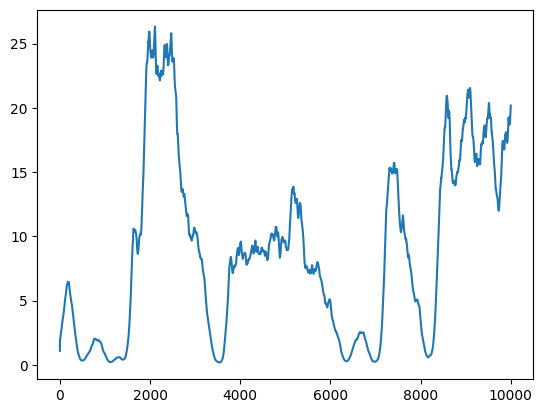

[[  0.   0. 513.]
 [  0.   7. 441.]]
[[521. 584. 498.]
 [434. 280. 454.]]
[[[1000. 1000. 1000.]
  [ 984.  989.  994.]
  [ 482.  478.  494.]]

 [[ 971.  975.  963.]
  [ 988.  971.  779.]
  [ 451.  434.  420.]]]


In [16]:
it_av = 1000
M_val = 400
it = 80

# if counters are recomputed, make sure to set them to zero
#counter_doc = np.zeros((2, 3))
#counter_noinput = np.zeros((2, 3))
#counter_noc = np.zeros((2, 3, 3))

# 18 cases to be computed; this will take many hours
for ci in range(2):

    for si, sigma in enumerate(sigma_array):
        aln = ALNModel()
        setinitstate(aln, data["init_state"][ci])
        aln.params["mue_ext_mean"] =  data["coordinates"][0]
        aln.params["mui_ext_mean"] =  data["coordinates"][1]
        aln.params.duration = duration
        aln.params["sigma_ou"] =  sigma

        aln.params["ext_exc_current"] = np.zeros_like(data["control"][ci].copy()[:,0,:])

        for k in range(it_av):
            aln.run()
            if ci == 0:
                if aln.rates_exc[0,-1] < 12:
                    counter_noinput[ci, si] += 1
            else:
                if aln.rates_exc[0,-1] > 14.:
                    counter_noinput[ci, si] += 1

        aln.params["ext_exc_current"] = data["control"][ci].copy()[:,0,:]

        for k in range(it_av):
            aln.run()
            if ci == 0:
                if aln.rates_exc[0,-1] < 12:
                    counter_doc[ci, si] += 1
            else:
                if aln.rates_exc[0,-1] > 14:
                    counter_doc[ci, si] += 1

        aln.params["ext_exc_current"] = np.zeros_like(data["control"][ci].copy()[:,0,:])
        aln.run()

        for mi, m in enumerate(M_array):

            if type(control_array[ci][si][mi]) is not type(None): continue

            aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat, 
                                        M=M_array[si], M_validation=M_val, validate_per_step=True
                                        )
            aln_controlled.weights["w_p"] = 0.
            aln_controlled.weights["w_2"] = 1.
            if ci == 0:
                aln_controlled.weights["w_f_osc"] = 1e3
            elif ci == 1:
                aln_controlled.weights["w_f_osc"] = -1.
            aln_controlled.maximum_control_strength = max_cntrl
            aln_controlled.optimize(0)

            for k in [0,4]:
                aln_controlled.zero_step_encountered = False
                aln_controlled.step = 10**(k)
                aln_controlled.optimize(4)

            if ci == 0:
                control_ = aln_controlled.control.copy()
                aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat, 
                                        M=M_array[si], M_validation=M_val, validate_per_step=True
                                        )
                aln_controlled.weights["w_p"] = 0.
                aln_controlled.weights["w_2"] = 1.
                aln_controlled.weights["w_f_osc"] = 1e2
                aln_controlled.maximum_control_strength = max_cntrl
                aln_controlled.control = control_.copy()
                aln_controlled.update_input()
                aln_controlled.optimize(0)

            aln_controlled.step = 10**(1)
            aln_controlled.optimize(it)

            control_array[ci][si][mi] = aln_controlled.control.copy()

            plt.plot(aln_controlled.get_xs()[0,0,:])
            plt.show()

            aln.params["ext_exc_current"] = aln_controlled.control.copy()[:,0,:]

            for k in range(it_av):
                aln_controlled.model.run()
                if ci == 0:
                    if aln_controlled.model.rates_exc[0,-1] < 12:
                        counter_noc[ci, si, mi] += 1
                else:
                    if aln_controlled.model.rates_exc[0,-1] > 14:
                        counter_noc[ci, si, mi] += 1

            with open(os.path.join(datadir, 'data_noisy.pickle'), 'wb') as handle:
                pickle.dump([control_array, counter_noinput, counter_doc, counter_noc], handle)

In [17]:
# save results into file
with open(os.path.join(datadir, 'data_noisy.pickle'), 'wb') as handle:
    pickle.dump([control_array, counter_noinput, counter_doc, counter_noc], handle)

In [ ]:
# read control signals from file
with open(os.path.join(datadir, 'data_noisy.pickle'), 'rb') as handle:
    [control_array, counter_noinput, counter_doc, counter_noc] = pickle.load(handle)

We plot the results to qualitatively compare the performances of the noisy optimal control (NOC) for different noise strengths and realizations to average over ($M$).

Activity plots show 20 realizations of controlled activity.

Text(0.5, 1.0, '$M = $30')

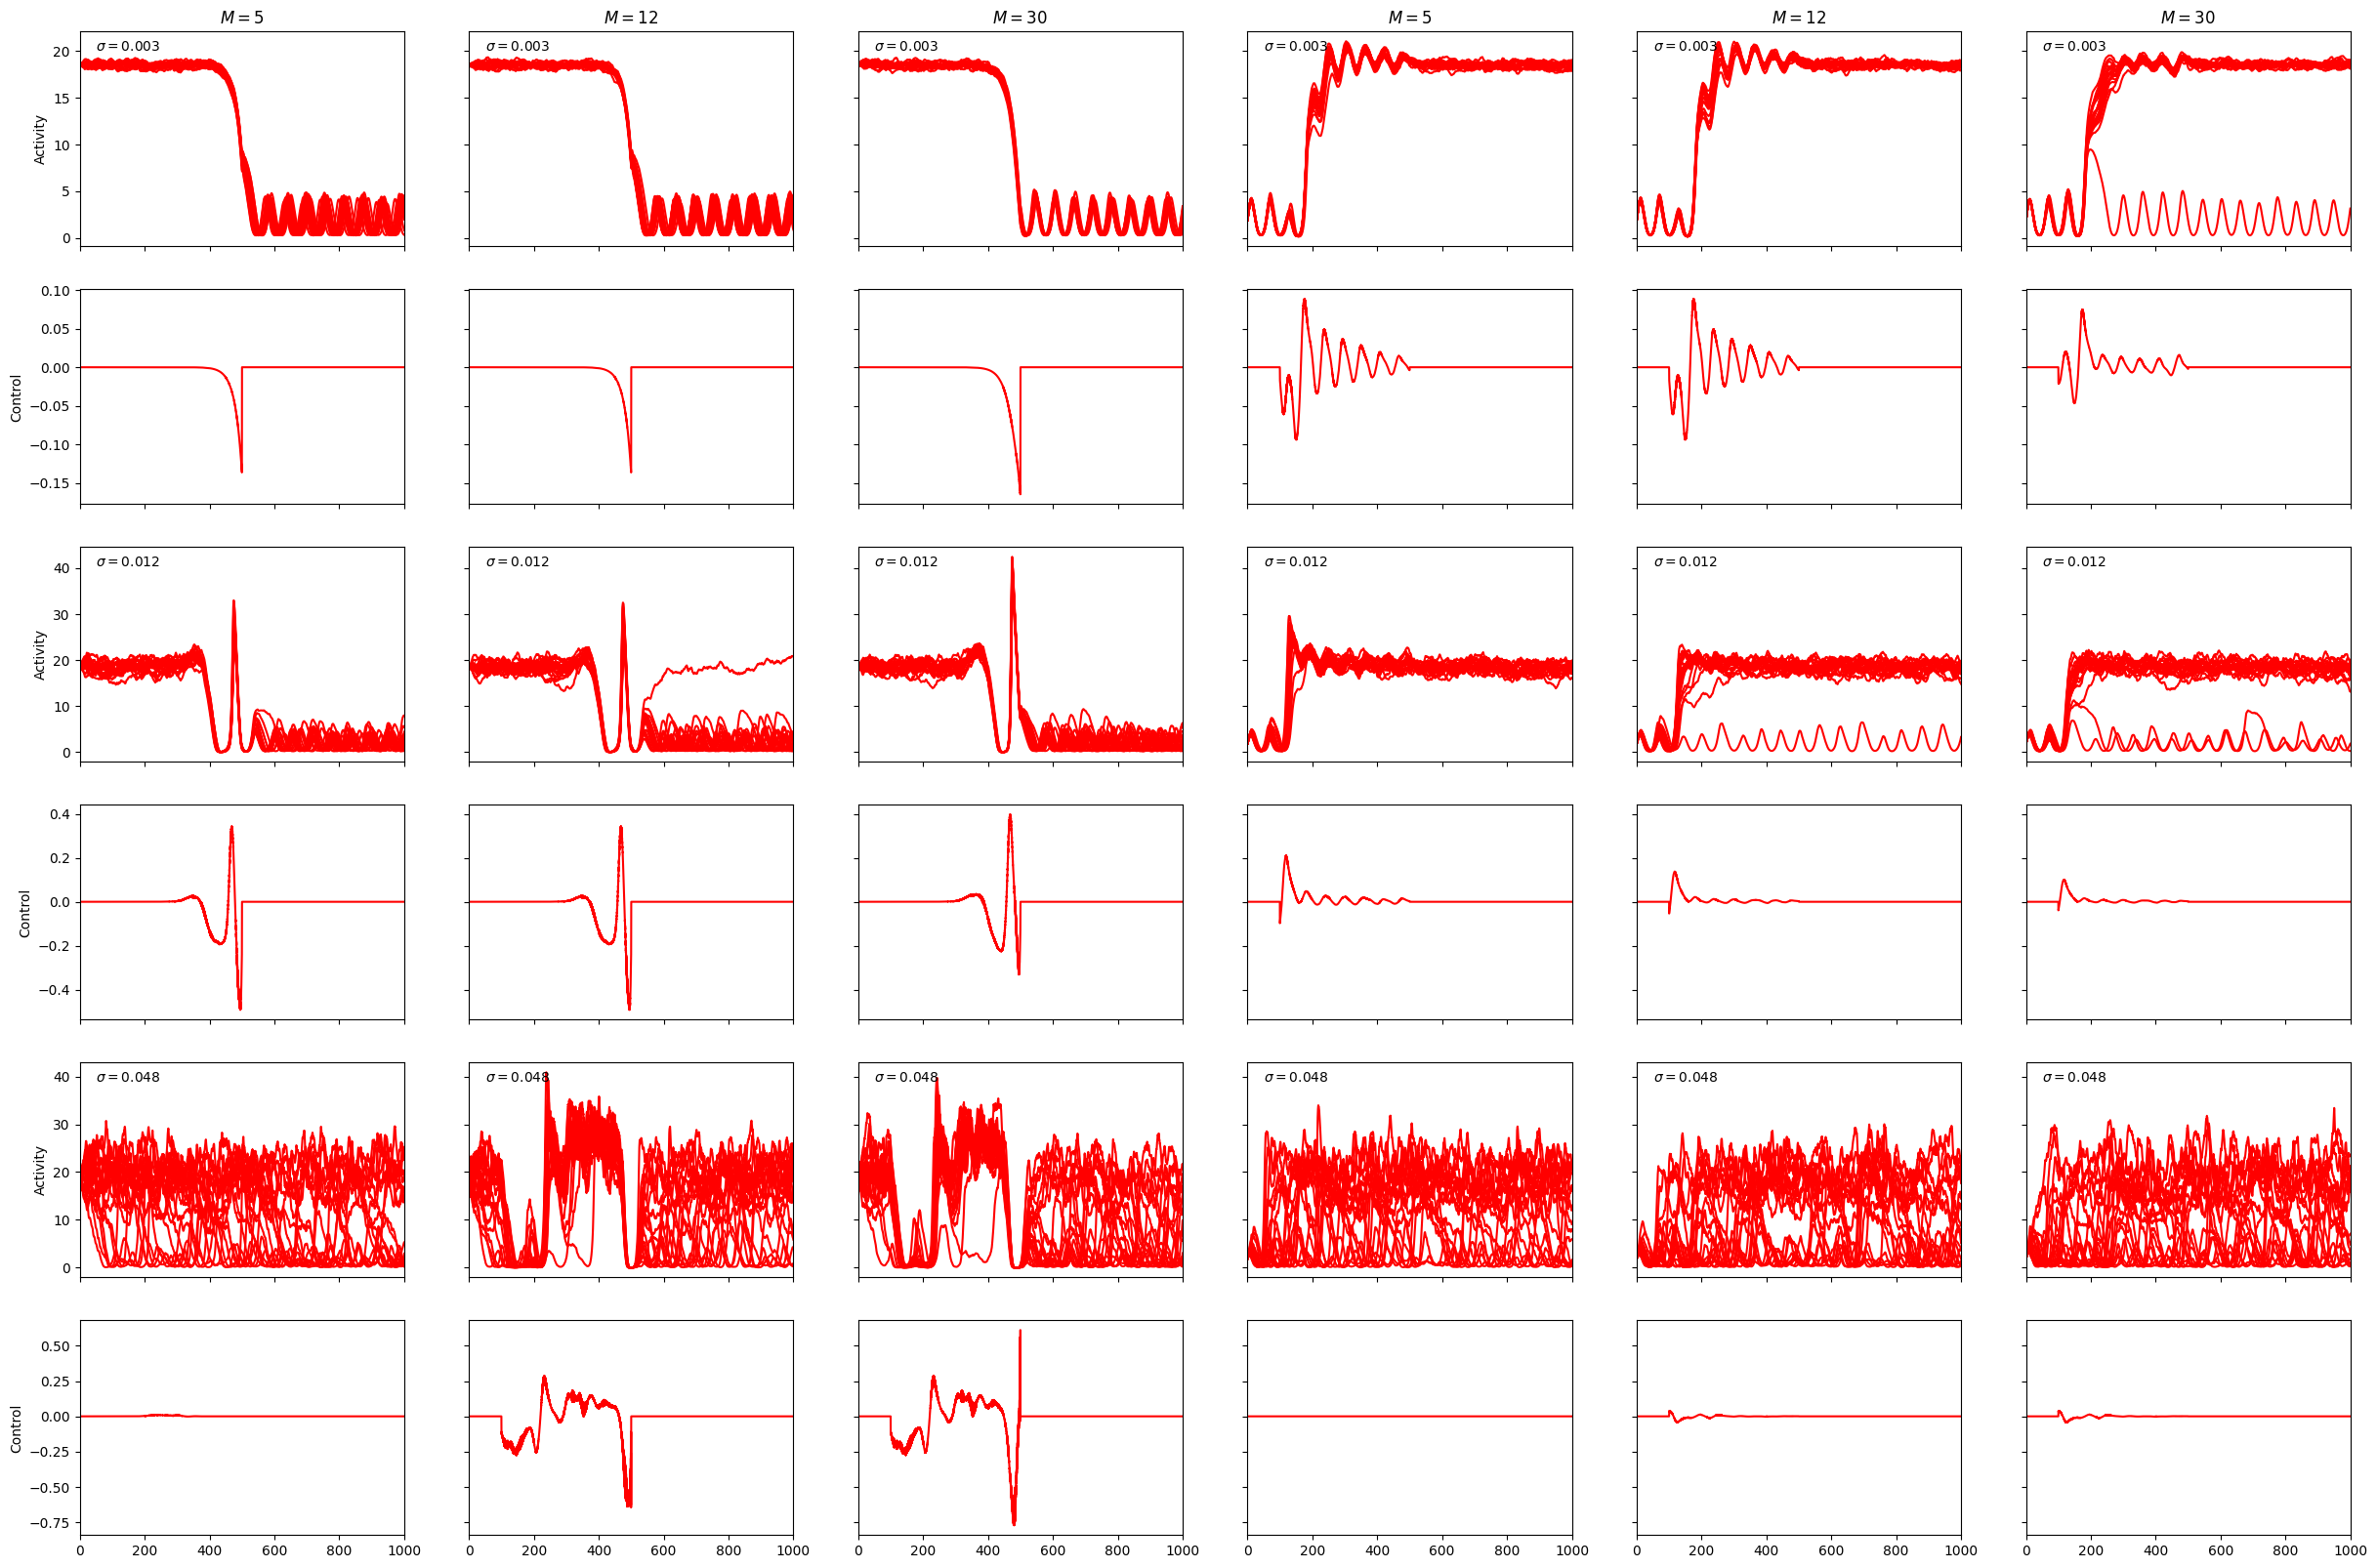

In [19]:
fig, ax = plt.subplots(6, 6, figsize=(30, 20), sharex=True, sharey="row")

for si, sigma in enumerate(sigma_array):
    for mi, m in enumerate(M_array):
        for ci in range(2):
            if type(control_array[ci][si][mi]) is type(None): continue

            aln = ALNModel()
            setinitstate(aln, data["init_state"][ci])
            aln.params["mue_ext_mean"] =  data["coordinates"][0]
            aln.params["mui_ext_mean"] =  data["coordinates"][1]
            aln.params.duration = duration
            aln.params["sigma_ou"] =  sigma

            aln.params["ext_exc_current"] = control_array[ci][si][mi][:,0,:].copy()

            for k in range(20):
                aln.run()
            
                ax[2*si, 3*ci+mi].plot(aln.t, aln.rates_exc[0, :], color="red")
            ax[2*si+1, 3*ci+mi].plot(aln.t, control_array[ci][si][mi][0,0,1:], color="red")
            ax[2*si, 3*ci+mi].text(0.05, 0.93, r"$\sigma = $" + str(sigma), horizontalalignment='left', verticalalignment='center', transform=ax[2*si, 3*ci+mi].transAxes)


ax[0,0].set_ylabel("Activity")
ax[2,0].set_ylabel("Activity")
ax[4,0].set_ylabel("Activity")
ax[1,0].set_ylabel("Control")
ax[3,0].set_ylabel("Control")
ax[5,0].set_ylabel("Control")

ax[0,0].set_xlim(0, duration)

ax[0,0].set_title(r"$M = $" + str(M_array[0]))
ax[0,1].set_title(r"$M = $" + str(M_array[1]))
ax[0,2].set_title(r"$M = $" + str(M_array[2]))
ax[0,3].set_title(r"$M = $" + str(M_array[0]))
ax[0,4].set_title(r"$M = $" + str(M_array[1]))
ax[0,5].set_title(r"$M = $" + str(M_array[2]))